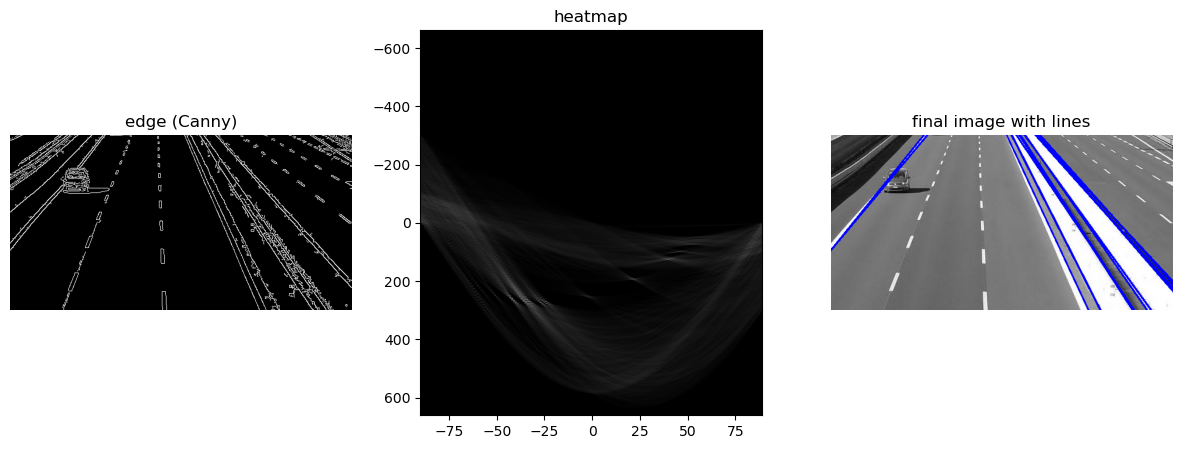

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("input.png", cv2.IMREAD_GRAYSCALE)

# استخراج لبه‌ ها (Canny)
edges = cv2.Canny(image, 50, 150)

# هاف
height, width = edges.shape

diag_len = int(np.ceil(np.sqrt(height**2 + width**2)))

rhos = np.arange(-diag_len, diag_len + 1, 1)
thetas = np.deg2rad(np.arange(-90, 90, 1))

accumulator = np.zeros((len(rhos), len(thetas)))

cos_t = np.cos(thetas)
sin_t = np.sin(thetas)

# شمارش 
ys, xs = np.nonzero(edges)

for i in range(len(xs)):
    x = xs[i]
    y = ys[i]

    for t in range(len(thetas)):
        rho = int(round(x * cos_t[t] + y * sin_t[t]))
        accumulator[rho + diag_len, t] += 1

# پیدا کردن قله‌ ها
threshold = int(accumulator.max() * 0.5)

lines = []

for r in range(accumulator.shape[0]):
    for t in range(accumulator.shape[1]):
        if accumulator[r, t] >= threshold:
            lines.append((r - diag_len, thetas[t]))

# رسم خطوط روی تصویر
output = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

for rho, theta in lines:

    a = np.cos(theta)
    b = np.sin(theta)

    x0 = a * rho
    y0 = b * rho

    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))

    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))

    cv2.line(output, (x1, y1), (x2, y2), (255, 0, 0), 2)

# نمایش نتایج
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(edges, cmap="gray")
plt.title("edge (Canny)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(
    accumulator,
    cmap="gray",
    aspect="auto",
    extent=[-90, 89, rhos[-1], rhos[0]]
)
plt.title("heatmap")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("final image with lines")
plt.axis("off")

plt.show()